# CSC115 Unit 10.4 - Python Error Handling
    
* #### **Today**: 
    - Error handling with `try`/`except`<br><br>
    
* #### **This Unit**:
    - 2D arrays
    - 3D arrays
    - Intro to images
    - Arrays and functions
    - File reading
    - Exception Handling<br><br>


* #### **Upcoming**: 
    - **Lab Adv 6 part C** - final program - due Tuesday
    - <a href="https://sdbor.campuslabs.com/eval-home/">IDEA Surveys Out - % BONUS</a>
        - 60% = +2 bonus
        - 70% = +3 bonus
        - 80% = +4 bonus
        - 90% = +5 bonus
        - 100% = +10 bonus<br><br>

    - **PostQuiz 10** Friday
    - **Exam 3** - Monday 
    - ***Final Exam***
        - Monday May 4
        - 10-11:50am
        - Room EEP252/3/4

    
<br>


#### You will need the following files:
* system_data_2.txt
  

<br>
<hr>
<br>
    


<center><img src ="https://i.postimg.cc/jqh9H7qD/And-Now-For-Something-Completely-Different-Z8-Wfkuk7-subtitled.jpg" width=50%></center>
    
<br>

<font size=5>**Attendance Quiz Password**:  *********** </font>

<br>

<hr>

#### Let's get our working directory setup

In [1]:
import os
import numpy as np

try:
    # works for py files
    print(f"Changing directory using '__file__'")
    os.chdir(os.path.dirname(__file__))
    
except Exception as e:
    print(f"Error: {e}")

    # works for ipynb
    print(f"Trying alternative method using '__vsc_ipynb_file__'")
    os.chdir(os.path.dirname(globals()["__vsc_ipynb_file__"]))
finally:
    print(f"CWD: {os.getcwd()}")

Changing directory using '__file__'
Error: name '__file__' is not defined
Trying alternative method using '__vsc_ipynb_file__'
CWD: c:\Users\101227284\OneDrive - SDSMT\Software Development I\Unit 10


<br>

## 🤦‍♂️ Catching Errors
Not everything you try to execute in Python will work
- **File errors** - file not found, problem reading the file
- **Math errors** - division by zero, overflow, index out of bounds
- **Type conversions errors** - wrong data type

<br>

<center><img src="https://i.postimg.cc/L6dCnfdj/09-file-not-found-error.jpg" width=700></center>
    
<br>

#### Example: dividing numbers

In [2]:
num = int(input("Enter numerator: "))
denom = int(input("Enter the denominator: "))

result = num / denom

print(f"{num} divided by {denom} is {result}")

7 divided by 9 is 0.7777777777777778


#### These errors are called **"Exceptions"** and we want to catch them

<img src="https://i.postimg.cc/x8X4WKzg/10-04-exceptions.jpg" alt='exceptions' width=300>

<br>

## 😨 The `try/except` mechanism can be used to detect and handle errors
- This allows programs to gracefully deal with them
- No more <font color="red">kaboom</font> messages

<br>

#### 🛠️ Simple `try/except` block:
```Python
    try:
        attempt to do some code that could cause an error

    except:
        what to do if that error happens

```


#### 🛠️ In full form:
```Python
    try:
        attempt to do some code that could cause an error

    except:
        what to do if that error happens

    else:
        what to do if there is NO error

    finally:
        do this regardless if an error occurred or not

```

<br>

#### Some common **exceptions** maybe you've already encountered:
- ValueError
- ZeroDivisionError
- NameError
- FileNotFoundError
- IndexError

You can learn more at <a href="https://www.w3schools.com/python/python_try_except.asp">W3Schools HERE</a><br>
You can find a list of exceptions <a href="https://docs.python.org/3/library/exceptions.html"> HERE</a>

<br>

### Ask the user for an integer and print it
* What happens when you enter a string instead?

In [3]:
num = int(input("Enter number: "))
print("Your number was:", num)

Your number was: 8


* Catch **ANY** exception

In [5]:
try:
    num = int(input("Enter number: "))
    print("Your number was:", num)
except ValueError:
    print("You broke it")

You broke it


<br><hr><br>

<table border=0 width=100%><tr><td bgcolor="green" align=center><font size=5 color=white><b>You Try</b></td></tr></table>

<br>

#### 1. Write a try/except block to catch the exception when we divide by zero

In [8]:
# same code as above.  Crashes when divided by 0
try:
    num = int(input("Enter numerator: "))
    denom = int(input("Enter the denominator: "))
    result = num / denom
    print(f"{num} divided by {denom} is {result}")
except ValueError:
    print("Please enter valid integers.")
except ZeroDivisionError:
    print("Denominator cannot be zero.")

Denominator cannot be zero.


<br><hr><br>

#### You can catch specific exceptions by putting the name after the `except` keyword
* Enter an index to change to 0
* What happens when our index exceeds the array length?
    * What exception do we get?

In [10]:
ar = np.arange(1,24,1)

print("original:", ar)
n = int(input("Which element to change to 0: "))

ar[n] = 0
print("modified:", ar)

original: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


IndexError: index 999999 is out of bounds for axis 0 with size 23

<br>

#### fixed version with `try/except` catching the specific error

In [11]:
# fixed version with try/except

print("original:", ar)
n = int(input("Which element to change to 0: "))

try:
    ar[n] = 0
    print("modified:", ar)
    
except IndexError:
    print(f"index {n} is out of range")

original: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
index 9999 is out of range


<br>

#### But we miss other errors that could occur
* What other exceptions could we have?
* Good to catch **generic errors** too

    > We can have **multiple Exception** statements

In [15]:
print("original:", ar)
n = int(input("Which element to change to 0: "))

try:
    ar[n] = 0
    print("modified:", ar)
    
except IndexError:
    print(f"index {n} is out of range")

## other exceptions
except ValueError:
    print(f"index must be an integer")

except Exception as e:
    print(f"some other error happened: {e}")

original: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


ValueError: invalid literal for int() with base 10: 'hirk'

<br><hr><br>

<table border=0 width=100%><tr><td bgcolor="green" align=center><font size=5 color=white><b>You Try</b></td></tr></table>

<br>

#### 1. Write a try/except block for the zero division problem above that catches:
* ZeroDivisionError - when divide by Zero
* ValueError - not a valid number
* Generic exception - for anything else

In [17]:
# complete the rest of the code
try:
    num = int(input("Enter numerator: "))
    denom = int(input("Enter the denominator: "))

    result = num / denom

    print(f"{num} divided by {denom} is {result}")
except ValueError:
    print("Please enter valid integers.")
except ZeroDivisionError:
    print("Denominator cannot be zero.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


432613464 divided by 4151467137 is 0.10420736807581285


<br><hr><br>

#### Use `else` for when no error occurs

In [18]:
print("original:", ar)
n = int(input("Which element to change to 0: "))

try:
    ar[n] = 0
    print("modified:", ar)
    
except IndexError:
    print(f"index {n} is out of range")
except ValueError:
    print(f"index must be an integer")
except:
    print("some other error happened")

else:
    print("No error occurred")

original: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
modified: [ 1  2  3  4  5  6  0  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
No error occurred


<br><hr><br>

## 📂 What About a File That Does not Exist?

In [19]:
import numpy as np

data2 = np.loadtxt("somefile.txt") # this will give an Exception

FileNotFoundError: somefile.txt not found.

<br>

### Catch the **FileNotFoundError**


In [20]:
# this will give an FileNotFoundError but we will catch it

filename = 'somefile.txt'

try: 
    data2 = np.loadtxt( filename ) 

except FileNotFoundError:  # also IOError
    print("Cannot find", filename)
    
else:
    # Get the time samples from column 0
    ts = data2[:,0]

    # Get the values of f(t) for each time sample from column 1
    ft = data2[:,1]

Cannot find somefile.txt


<br><hr><br>

## 🎯 We can catch a *generic* error and see the **specific error message**
* Use `except Exception as e:`


In [21]:
# this will give an ValueError but we will catch it

filename = 'system_data_2.txt'

try: 
    data2 = np.loadtxt( filename ) 

except FileNotFoundError: 
    print( f"Cannot find {filename}" )
    
# add the general exception
except Exception as e:
    print(f"An exception occurred: {e}")
    print(f"The error type was: {type(e).__name__}")
    
else:
    # Get the time samples from column 0
    ts = data2[:,0]

    # Get the values of f(t) for each time sample from column 1
    ft = data2[:,1]

An exception occurred: could not convert string 'Time' to float64 at row 0, column 1.
The error type was: ValueError


<br><hr><br>

<table border=0 width=100%><tr><td bgcolor="green" align=center><font size=5 color=white><b>You Try</b></td></tr></table>

<br>

#### 1. Modify the zero division problem to print the full Exception message and type
* Add an `else` for when no error occurs

In [24]:
# 
try:
    num = int(input("Enter numerator: "))
    denom = int(input("Enter the denominator: "))

    result = num / denom

    print(f"{num} divided by {denom} is {result}")
except ValueError:
    print("Please enter valid integers.")
except ZeroDivisionError:
    print("Denominator cannot be zero.")
else:
    print("No error occurred")

Please enter valid integers.


<br><hr><br>

#### Combine everything to perform a safe NumPy file read using `finally`
* Check that read was done correctly
* Add a `finally` to print that we are done reading the file

In [25]:
# safely reading file
filename = 'system_data_2.txt'

try:
    # read file
    data = np.loadtxt( filename )
    
except FileNotFoundError:
    print( f"Couldn't find the file {filename}, ending program" )
    
except ValueError:
    # data has header, skip it
    print( "Cannot convert header into numbers" )
    print( "Skipping first row" )
    data = np.loadtxt( filename, skiprows = 1 )
    print( data )
    
except Exception as e:
    print( "Some other exception occurred, ending program", e )
    
else:
    # success
    print( "We read this file successfully" )
    print( data )
    
finally:
    # last message
    print( "We finished the try/except block" )


Cannot convert header into numbers
Skipping first row
[[0.         3.10442292]
 [0.05102041 3.37983986]
 [0.10204082 3.79733115]
 [0.15306122 4.52694075]
 [0.20408163 4.69856041]
 [0.25510204 4.70787916]
 [0.30612245 5.35541523]
 [0.35714286 5.39991535]
 [0.40816327 5.58755109]
 [0.45918367 5.48607909]
 [0.51020408 5.67783117]
 [0.56122449 6.02323647]
 [0.6122449  5.86617266]
 [0.66326531 5.86939173]
 [0.71428571 6.27794733]
 [0.76530612 5.93155281]
 [0.81632653 6.21932393]
 [0.86734694 5.82295609]
 [0.91836735 6.06323468]
 [0.96938776 6.00387937]
 [1.02040816 5.69058704]
 [1.07142857 5.83448753]
 [1.12244898 5.59424206]
 [1.17346939 5.46088582]
 [1.2244898  5.65307086]
 [1.2755102  5.12350977]
 [1.32653061 5.42893257]
 [1.37755102 5.35816872]
 [1.42857143 5.14021531]
 [1.47959184 5.06387683]
 [1.53061224 4.72720762]
 [1.58163265 4.89211031]
 [1.63265306 4.72805803]
 [1.68367347 5.02129743]
 [1.73469388 4.66342119]
 [1.78571429 4.59730684]
 [1.83673469 4.5858679 ]
 [1.8877551  4.682068

<br><hr><br>

<table border=0 width=100%><tr><td bgcolor="green" align=center><font size=5 color=white><b>You Try</b></td></tr></table>

<br>

### 1. Use `try` to open a nonexistent file with `np.loadtxt`
* Read your file *"nofile.txt"*

* Catch the `FileNotFoundError`
* Catch any other exceptions and display the error message
* Print that you successfully read the file in an `else` block
* Use `finally` to display that you are done

In [26]:
# safely reading file
filename = "nofile.txt"

try:
    data = np.loadtxt( filename )
    
except FileNotFoundError:
    print( f"Couldn't find the file {filename}, ending program" )
    
except Exception as e:
    print( "Some other error occurred", e )
    
else:
    print( "We read this file successfully" )
    print( data )

finally:
    print( "We finished the try/except block" )

Couldn't find the file nofile.txt, ending program
We finished the try/except block


<br>

### 2. Try to plot the function $y$ = $sin(2x)$ <u>without</u> first importing the `matplotlib` library.
* Make your $x$ array $-\pi$ to $\pi$
* What exception does it raise?<br><br>

* Use try/except to catch this exception specifically
    * When you catch it, import `matplotlib.pyplot` and try to plot again
* Give a general exception as well that will display the exception message
* In a `finally` block, `show` the plot


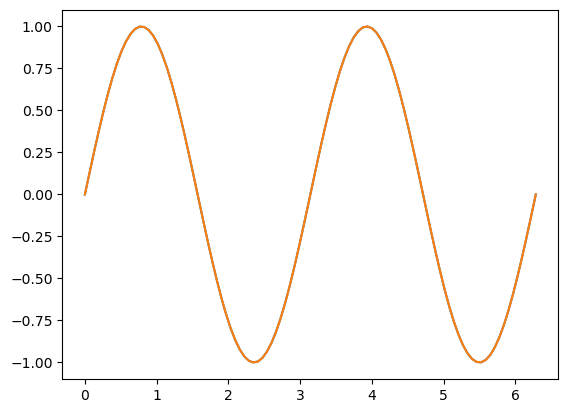

In [32]:
x = np.linspace( 0, 2*np.pi, 100 )
y = np.sin( 2 * x )

try:
    # plot x vs y
    plt.plot( x, y )


except NameError:
    print( "Matplotlib.pyplot not imported, importing anyway")

    # import matplotlib and try to plot again
    import matplotlib.pyplot as plt
    plt.plot( x, y )

except Exception as e:
    print( "Some exception occurred", e )
    
finally:
    # display the plot
    plt.plot( x, y )
    plt.show()